# ✈️ Part 3 — Mobility Network & Graph Mining
**MoMD Algorithms Applied:**
- **PageRank** (power iteration, implemented from scratch — MoMD Ch.5)
- **Topic-Sensitive PageRank** variant: teleport bias toward high-flu countries
- **Girvan-Newman** community detection via edge betweenness
- **Sparse matrix operations** for large graph scalability

**Owner**: Person 3 | **Outputs**: `graph_metrics.parquet`, `mobility_features.parquet`

In [1]:
!pip install networkx scipy pyarrow matplotlib requests pycountry -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 51.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import requests, pycountry
from collections import defaultdict
import warnings; warnings.filterwarnings('ignore')

FLUNET_IN  = '/kaggle/input/notebooks/phongngtun/infuenza-era5-processing/flunet_clean.parquet'
OUTPUT_DIR = '/kaggle/working/'
print('Libraries loaded ✓')

Libraries loaded ✓


## 3.1 Build Country Mobility Graph (OpenFlights)

In [3]:
def fetch_openflights():
    airports_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'
    routes_url   = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'
    from io import StringIO
    apt_cols = ['id','name','city','country','iata','icao','lat','lon','alt','tz','dst','tzname','type','source']
    rte_cols = ['airline','airline_id','src','src_id','dst','dst_id','codeshare','stops','equip']
    airports = pd.read_csv(StringIO(requests.get(airports_url).text), header=None, names=apt_cols, na_values=['\\N',''])
    routes   = pd.read_csv(StringIO(requests.get(routes_url).text),   header=None, names=rte_cols, na_values=['\\N',''])
    return airports, routes

airports, routes = fetch_openflights()

# Map IATA → ISO3
def name_to_iso3(name):
    try: return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except: return None

country_iso3_map = {name: name_to_iso3(name) for name in airports['country'].dropna().unique()}
airports['iso3'] = airports['country'].map(country_iso3_map)
iata_iso3 = airports.dropna(subset=['iata','iso3']).drop_duplicates('iata').set_index('iata')['iso3'].to_dict()

routes['src_iso3'] = routes['src'].map(iata_iso3)
routes['dst_iso3'] = routes['dst'].map(iata_iso3)
routes_cc = routes.dropna(subset=['src_iso3','dst_iso3']).query('src_iso3 != dst_iso3').copy()

# Normalize direction for undirected weight count
routes_cc[['a','b']] = pd.DataFrame(
    routes_cc.apply(lambda r: sorted([r['src_iso3'],r['dst_iso3']]), axis=1).tolist(),
    index=routes_cc.index
)
edge_weights = routes_cc.groupby(['a','b']).size().reset_index(name='route_count')
print(f'Edges: {len(edge_weights):,} | Countries: {pd.concat([edge_weights.a,edge_weights.b]).nunique()}')

Edges: 2,125 | Countries: 214


In [4]:
# Build NetworkX + adjacency matrix
G = nx.DiGraph()  # Directed for PageRank
for _, row in edge_weights.iterrows():
    G.add_edge(row['a'], row['b'], weight=row['route_count'])
    G.add_edge(row['b'], row['a'], weight=row['route_count'])  # symmetric for this dataset

nodes = sorted(G.nodes())
n = len(nodes)
node_idx = {c: i for i, c in enumerate(nodes)}
print(f'Directed graph: {n} nodes, {G.number_of_edges()} edges')

Directed graph: 214 nodes, 4250 edges


## 3.2 PageRank — Power Iteration (from scratch)

**MoMD Ch.5** — The random surfer model:

$$r^{(t+1)} = \beta \cdot M \cdot r^{(t)} + \frac{1-\beta}{n} \mathbf{1}$$

- `M` = column-stochastic transition matrix (each column sums to 1)
- `β = 0.85` = damping factor (probability of following a link vs teleporting)
- Converges when `||r^{(t+1)} - r^{(t)}||₁ < ε`

**Sparse matrix** implementation: O(edges) per iteration, not O(n²).

In [5]:
def build_transition_matrix(G, nodes, node_idx):
    """
    Build sparse column-stochastic transition matrix M.
    M[i,j] = weight(j→i) / out_degree_weight(j)
    Dangling nodes (no out-edges) get uniform teleport column.
    """
    n = len(nodes)
    rows, cols, data = [], [], []

    for src in nodes:
        out_edges = list(G.out_edges(src, data='weight'))
        if not out_edges:
            # Dangling node: distribute equally to all (handled via teleport)
            continue
        total_weight = sum(w for _, _, w in out_edges)
        for _, dst, w in out_edges:
            rows.append(node_idx[dst])
            cols.append(node_idx[src])
            data.append(w / total_weight)

    M = sp.csc_matrix((data, (rows, cols)), shape=(n, n))
    return M


def pagerank_power_iteration(M, n, beta=0.85, max_iter=100, tol=1e-6, verbose=True):
    """
    Standard PageRank via power iteration.
    MoMD Ch.5 Algorithm 5.1
    """
    r = np.ones(n) / n          # uniform initial distribution
    teleport = np.ones(n) / n   # uniform teleport vector

    for it in range(max_iter):
        r_new = beta * M.dot(r) + (1 - beta) * teleport
        # Handle dangling nodes: redistribute their mass uniformly
        dangling_mass = 1.0 - r_new.sum()
        r_new += dangling_mass / n

        delta = np.abs(r_new - r).sum()
        r = r_new
        if verbose and (it+1) % 10 == 0:
            print(f'  Iteration {it+1:3d} | L1 delta = {delta:.2e}')
        if delta < tol:
            print(f'  Converged at iteration {it+1} (delta={delta:.2e})')
            break
    return r


print('Building transition matrix...')
M = build_transition_matrix(G, nodes, node_idx)
print(f'M: {M.shape}, nnz={M.nnz:,} ({M.nnz/(n*n)*100:.3f}% dense)')

print('\nRunning PageRank power iteration (β=0.85)...')
pr_scores = pagerank_power_iteration(M, n, beta=0.85, tol=1e-8)

pr_df = pd.DataFrame({'country_iso3': nodes, 'pagerank_score': pr_scores})
pr_df = pr_df.sort_values('pagerank_score', ascending=False).reset_index(drop=True)
pr_df['hub_rank'] = pr_df.index + 1

print('\nTop 20 Epidemic Hub Countries:')
print(pr_df.head(20).to_string(index=False))

Building transition matrix...
M: (214, 214), nnz=4,250 (9.280% dense)

Running PageRank power iteration (β=0.85)...
  Iteration  10 | L1 delta = 2.13e-03
  Iteration  20 | L1 delta = 3.75e-05
  Iteration  30 | L1 delta = 9.00e-07
  Iteration  40 | L1 delta = 2.34e-08
  Converged at iteration 43 (delta=7.86e-09)

Top 20 Epidemic Hub Countries:
country_iso3  pagerank_score  hub_rank
         USA        0.067494         1
         GBR        0.050065         2
         DEU        0.042718         3
         ESP        0.041158         4
         FRA        0.033286         5
         ITA        0.029029         6
         CHN        0.027399         7
         RUS        0.020895         8
         ARE        0.020826         9
         CAN        0.018064        10
         JPN        0.016561        11
         AUS        0.014943        12
         NLD        0.012837        13
         IND        0.012719        14
         KOR        0.012345        15
         MEX        0.012262   

## 3.3 Topic-Sensitive PageRank — Flu-Biased Teleport

**MoMD Ch.5**: Topic-Sensitive PageRank modifies the teleport vector to be  
non-uniform — biased toward **high-flu countries**. This gives higher rank to  
countries well-connected to active outbreak regions.

$$r^{(t+1)} = \beta \cdot M \cdot r^{(t)} + (1-\beta) \cdot \mathbf{e}_S$$

where `e_S` is a probability vector concentrated on high-flu countries.

In [6]:
def topic_sensitive_pagerank(M, n, nodes, node_idx, teleport_scores, beta=0.85, max_iter=100, tol=1e-6):
    """
    Topic-Sensitive PageRank.
    teleport_scores: dict {country: score} — e.g. recent flu case counts
    Teleport vector is proportional to flu burden.
    """
    # Build biased teleport vector
    e_s = np.zeros(n)
    for country, score in teleport_scores.items():
        if country in node_idx:
            e_s[node_idx[country]] = score
    if e_s.sum() > 0:
        e_s = e_s / e_s.sum()   # normalize to probability distribution
    else:
        e_s = np.ones(n) / n    # fallback: uniform

    r = np.ones(n) / n
    for it in range(max_iter):
        r_new = beta * M.dot(r) + (1 - beta) * e_s
        dangling_mass = 1.0 - r_new.sum()
        r_new += dangling_mass * e_s  # redistribute via biased teleport
        delta = np.abs(r_new - r).sum()
        r = r_new
        if delta < tol:
            print(f'  Converged at iteration {it+1}')
            break
    return r


# Use latest FluNet data as teleport bias
flunet = pd.read_parquet(FLUNET_IN)
latest_flu = (
    flunet.sort_values(['year','week'])
    .groupby('country_iso3')['flu_cases_total']
    .last()
    .to_dict()
)

print('Running Topic-Sensitive PageRank (flu-biased teleport)...')
tspr_scores = topic_sensitive_pagerank(M, n, nodes, node_idx, latest_flu)

tspr_df = pd.DataFrame({'country_iso3': nodes, 'tspr_score': tspr_scores})
tspr_df = tspr_df.sort_values('tspr_score', ascending=False).reset_index(drop=True)

# Compare standard vs topic-sensitive ranking
comparison = pr_df[['country_iso3','pagerank_score','hub_rank']].merge(
    tspr_df[['country_iso3','tspr_score']], on='country_iso3'
).assign(tspr_rank=lambda x: x['tspr_score'].rank(ascending=False).astype(int))

print('\nTop 15: Standard PageRank vs Flu-Sensitive PageRank')
print(comparison.head(15).to_string(index=False))

Running Topic-Sensitive PageRank (flu-biased teleport)...
  Converged at iteration 31

Top 15: Standard PageRank vs Flu-Sensitive PageRank
country_iso3  pagerank_score  hub_rank  tspr_score  tspr_rank
         USA        0.067494         1    0.125613          1
         GBR        0.050065         2    0.050827          4
         DEU        0.042718         3    0.042587          5
         ESP        0.041158         4    0.040020          6
         FRA        0.033286         5    0.030924          7
         ITA        0.029029         6    0.028255          8
         CHN        0.027399         7    0.069499          3
         RUS        0.020895         8    0.018609         12
         ARE        0.020826         9    0.016059         13
         CAN        0.018064        10    0.089409          2
         JPN        0.016561        11    0.024777          9
         AUS        0.014943        12    0.009658         20
         NLD        0.012837        13    0.012580     

## 3.4 Community Detection — Girvan-Newman

**MoMD Ch.10**: Communities are found by iteratively removing edges with  
highest **edge betweenness centrality** (number of shortest paths passing through edge).

```
1. Compute edge betweenness for all edges
2. Remove edge with highest betweenness
3. Recompute betweenness
4. Repeat until modularity Q peaks
```

For large graphs: use **Louvain** (greedy modularity optimization) as efficient approximation.

In [7]:
# Use undirected graph for community detection
G_undirected = G.to_undirected()

# Girvan-Newman on manageable subgraph (top connected component)
# Full graph too large for exact Girvan-Newman → use on top 50 hubs
top50_hubs = pr_df.head(50)['country_iso3'].tolist()
G_hub = G_undirected.subgraph(top50_hubs).copy()
print(f'Hub subgraph: {G_hub.number_of_nodes()} nodes, {G_hub.number_of_edges()} edges')

# Girvan-Newman: iterative edge removal
def girvan_newman_modularity(G_orig, max_communities=8):
    """
    Run Girvan-Newman until we have max_communities communities or Q drops.
    Returns partition with best modularity Q.
    """
    from networkx.algorithms.community import girvan_newman
    G_work = G_orig.copy()
    best_Q = -1
    best_partition = None

    generator = girvan_newman(G_work)
    for step, communities in enumerate(generator):
        communities = list(communities)
        Q = nx.community.modularity(G_orig, communities, weight='weight')
        if Q > best_Q:
            best_Q = Q
            best_partition = communities
        print(f'  Step {step+1}: {len(communities)} communities, Q={Q:.4f}')
        if len(communities) >= max_communities:
            break
    print(f'\nBest partition: {len(best_partition)} communities, Q={best_Q:.4f}')
    return best_partition, best_Q


print('Running Girvan-Newman on hub subgraph...')
gn_partition, best_Q = girvan_newman_modularity(G_hub, max_communities=6)
gn_community_map = {node: i for i, comm in enumerate(gn_partition) for node in comm}

Hub subgraph: 50 nodes, 630 edges
Running Girvan-Newman on hub subgraph...
  Step 1: 2 communities, Q=-0.0000
  Step 2: 3 communities, Q=-0.0000
  Step 3: 4 communities, Q=0.0003
  Step 4: 5 communities, Q=-0.0000
  Step 5: 6 communities, Q=-0.0002

Best partition: 4 communities, Q=0.0003


In [8]:
# Full graph: Louvain / greedy modularity
print('Running Louvain-style community detection on full graph...')
try:
    from community import best_partition as louvain
    full_partition = louvain(G_undirected, weight='weight')
    method = 'Louvain'
except ImportError:
    !pip install python-louvain -q
    try:
        from community import best_partition as louvain
        full_partition = louvain(G_undirected, weight='weight')
        method = 'Louvain'
    except:
        comms = nx.community.greedy_modularity_communities(G_undirected, weight='weight')
        full_partition = {n: i for i, c in enumerate(comms) for n in c}
        method = 'Greedy Modularity'

community_df = pd.DataFrame.from_dict(full_partition, orient='index', columns=['community_id']).reset_index().rename(columns={'index':'country_iso3'})
print(f'{method}: {community_df["community_id"].nunique()} communities')

Running Louvain-style community detection on full graph...
Louvain: 6 communities


## 3.5 Mobility-Weighted Neighbor Flu Feature

In [9]:
flunet = pd.read_parquet(FLUNET_IN)
flunet[['year','week','flu_cases_total']] = flunet[['year','week','flu_cases_total']].apply(pd.to_numeric, errors='coerce')
flunet['flu_cases_total'] = flunet['flu_cases_total'].fillna(0)

flu_pivot = flunet.pivot_table(index=['year','week'], columns='country_iso3',
                                values='flu_cases_total', aggfunc='sum')

# Sparse adjacency matrix (undirected, weighted)
adj_pd = pd.DataFrame(
    nx.to_numpy_array(G_undirected, nodelist=nodes, weight='weight'),
    index=nodes, columns=nodes
)

common = [c for c in nodes if c in flu_pivot.columns]
flu_vals = flu_pivot[common].fillna(0).values
W = adj_pd.loc[common, common].values
np.fill_diagonal(W, 0)
row_sums = W.sum(axis=1, keepdims=True); row_sums[row_sums==0] = 1
W_norm = W / row_sums

mob_flu = flu_vals @ W_norm.T
mob_flu_df = (
    pd.DataFrame(mob_flu, index=flu_pivot.index, columns=common)
    .reset_index()
    .melt(id_vars=['year','week'], var_name='country_iso3', value_name='mob_weighted_neighbor_flu')
)
print(f'Mobility-weighted flu: {mob_flu_df.shape}')

Mobility-weighted flu: (16952, 4)


## 3.6 Visualization & Export

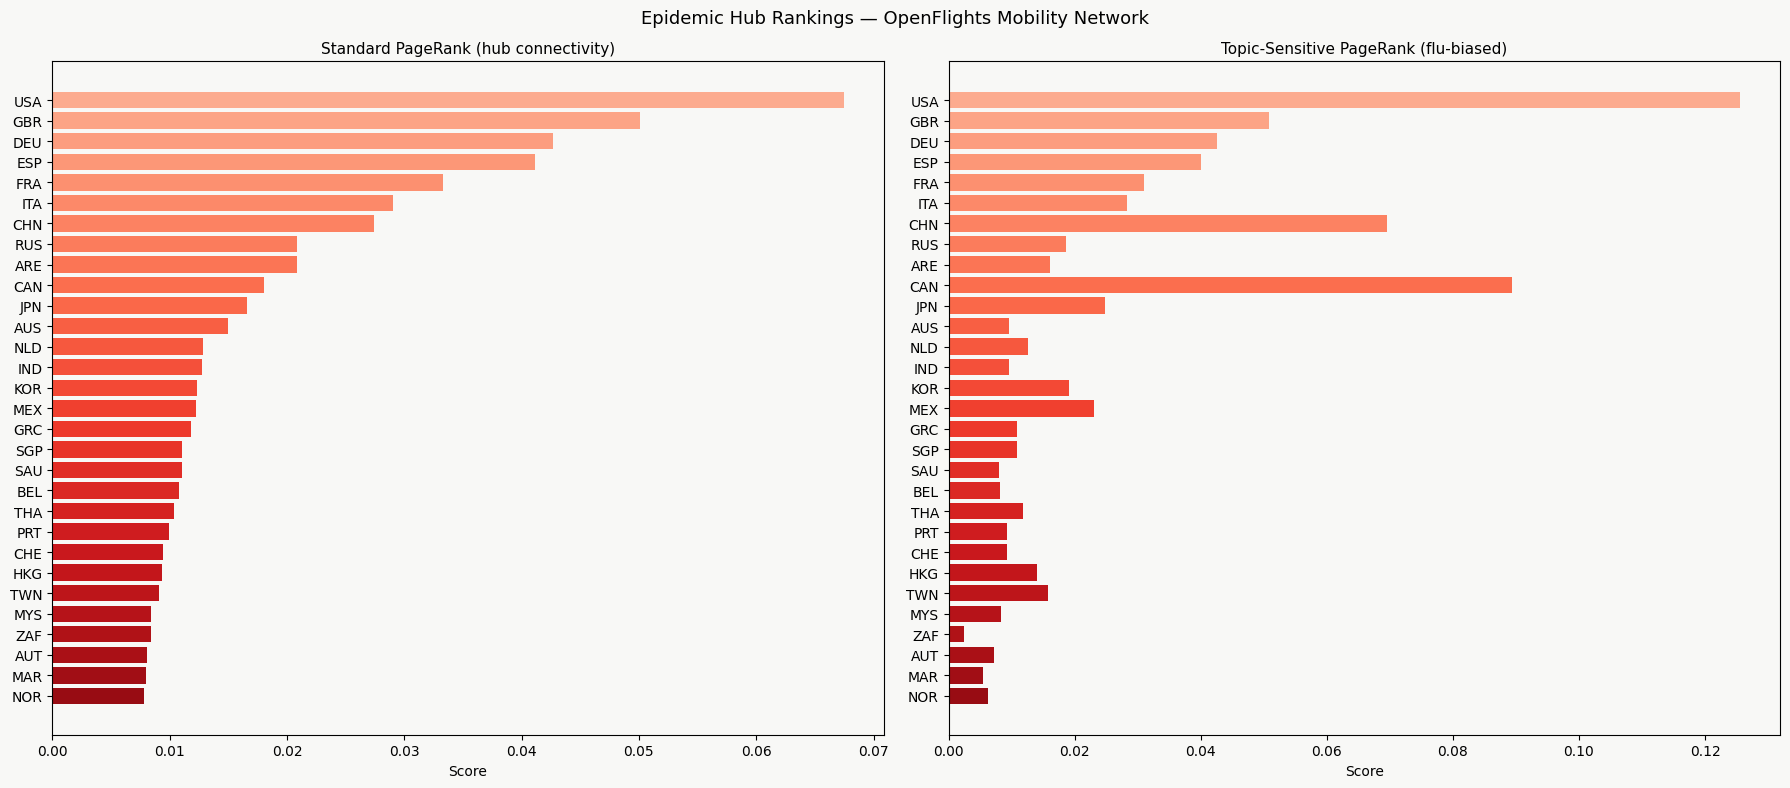

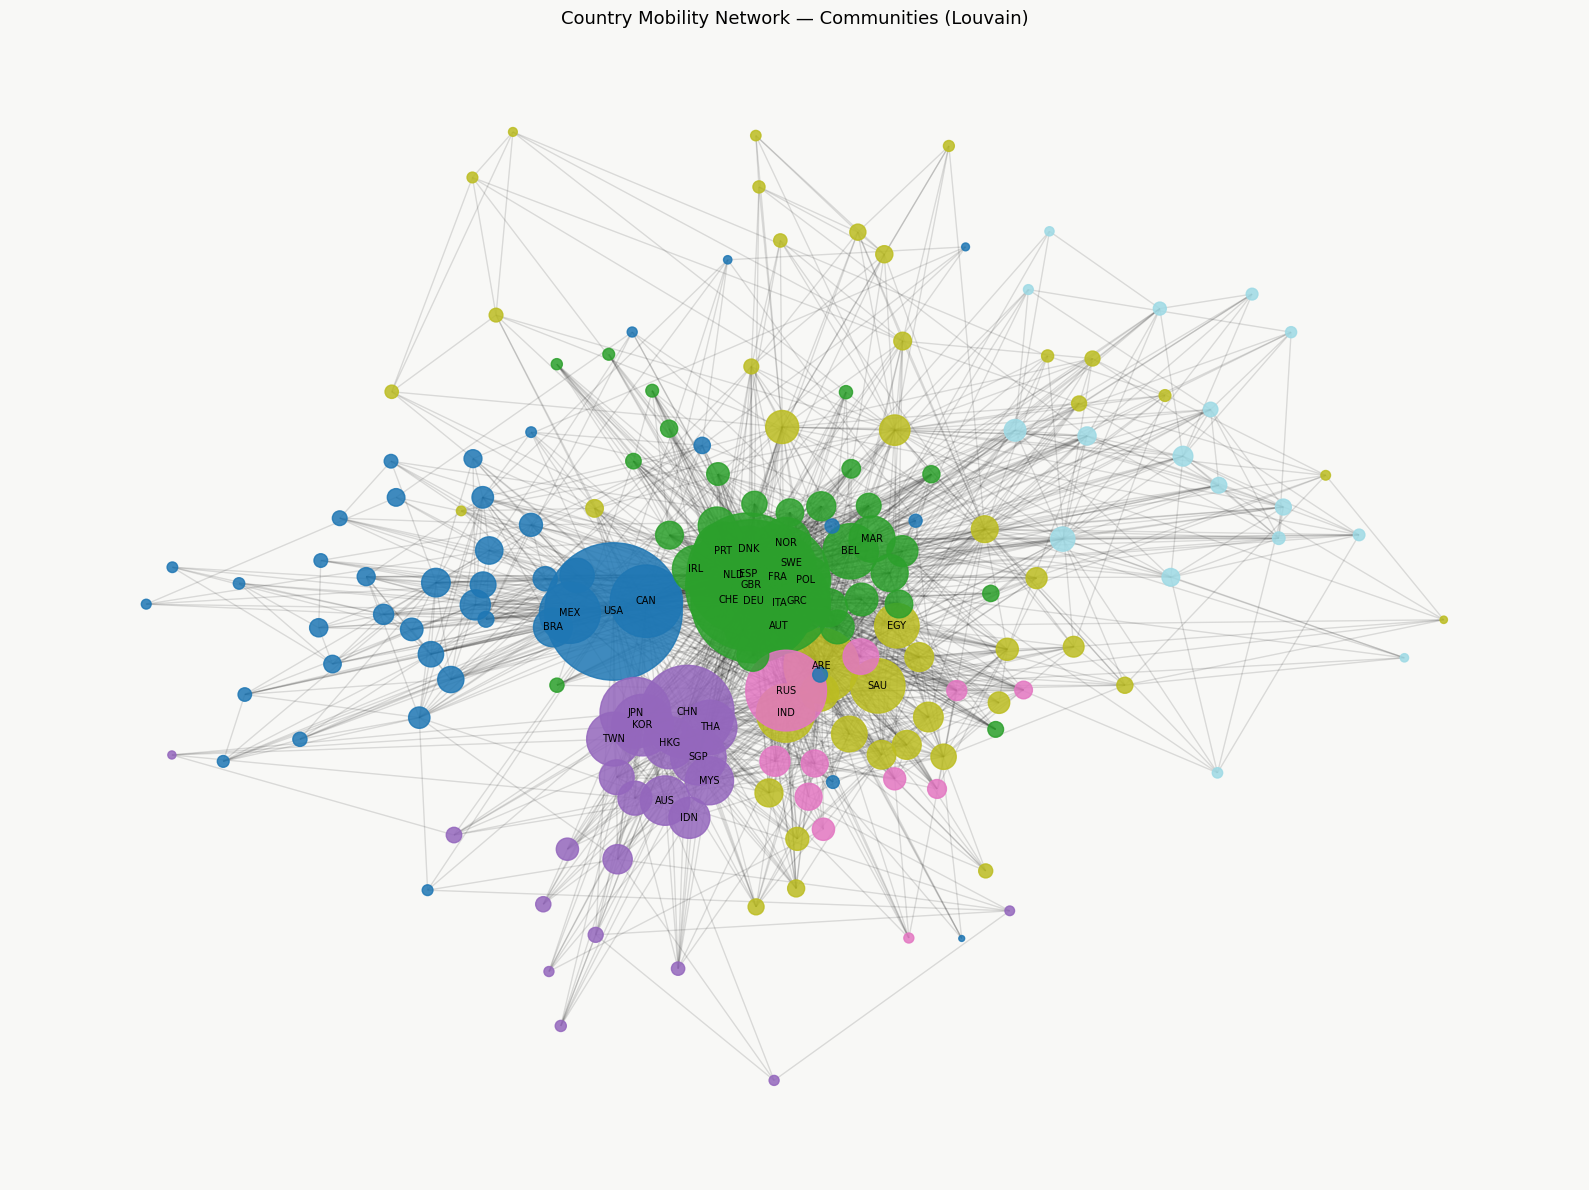

In [10]:
# Hub ranking bar chart
top30 = pr_df.head(30)
fig, axes = plt.subplots(1,2, figsize=(18,8))
for ax, (df_, col, title) in zip(axes, [
    (top30, 'pagerank_score', 'Standard PageRank (hub connectivity)'),
    (comparison.head(30), 'tspr_score', 'Topic-Sensitive PageRank (flu-biased)'),
]):
    colors = cm.Reds(np.linspace(0.3,0.9,len(df_)))[::-1]
    ax.barh(df_['country_iso3'][::-1], df_[col][::-1], color=colors)
    ax.set_title(title, fontsize=11); ax.set_xlabel('Score')
    ax.set_facecolor('#f8f8f6')
plt.suptitle('Epidemic Hub Rankings — OpenFlights Mobility Network', fontsize=13)
fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'pagerank_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Network visualization
high_deg = [n for n,d in G_undirected.degree() if d >= 5]
G_sub = G_undirected.subgraph(high_deg)
pos = nx.spring_layout(G_sub, k=0.5, seed=42, weight='weight')
node_comm = {n: full_partition.get(n,0) for n in G_sub.nodes()}
cmap = plt.cm.get_cmap('tab20', community_df['community_id'].nunique())

fig, ax = plt.subplots(figsize=(16,12))
nx.draw_networkx_edges(G_sub, pos, alpha=0.12, ax=ax)
nx.draw_networkx_nodes(G_sub, pos,
    node_color=[cmap(node_comm[n]) for n in G_sub.nodes()],
    node_size=[G_sub.degree(n,weight='weight')*2 for n in G_sub.nodes()],
    alpha=0.85, ax=ax)
labels = {n:n for n in G_sub.nodes() if G_sub.degree(n,weight='weight') > np.percentile(
    list(dict(G_sub.degree(weight='weight')).values()), 80)}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=7, ax=ax)
ax.set_title('Country Mobility Network — Communities (Louvain)', fontsize=13)
ax.axis('off'); fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'mobility_communities.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Graph metrics
betweenness = nx.betweenness_centrality(G_undirected, weight='weight', normalized=True)
graph_metrics = (
    pr_df
    .merge(tspr_df, on='country_iso3', how='outer')
    .merge(community_df, on='country_iso3', how='outer')
    .assign(
        betweenness=lambda x: x['country_iso3'].map(betweenness),
        degree_centrality=lambda x: x['country_iso3'].map(nx.degree_centrality(G_undirected)),
        route_strength=lambda x: x['country_iso3'].map(dict(G_undirected.degree(weight='weight'))),
    )
)

graph_metrics.to_parquet(OUTPUT_DIR+'graph_metrics.parquet', index=False)
mob_flu_df.to_parquet(OUTPUT_DIR+'mobility_features.parquet', index=False)
edge_weights.to_parquet(OUTPUT_DIR+'mobility_edges.parquet', index=False)

print('✅ graph_metrics.parquet     — PageRank (standard + topic-sensitive), communities')
print('✅ mobility_features.parquet — mob_weighted_neighbor_flu per country-week')
print('✅ mobility_edges.parquet    — edge list')
print(f'\nPageRank converged (sparse power iteration) for {n} countries')
print(f'Communities detected: {community_df["community_id"].nunique()} (Louvain) / {len(gn_partition)} (Girvan-Newman on hubs)')

✅ graph_metrics.parquet     — PageRank (standard + topic-sensitive), communities
✅ mobility_features.parquet — mob_weighted_neighbor_flu per country-week
✅ mobility_edges.parquet    — edge list

PageRank converged (sparse power iteration) for 214 countries
Communities detected: 6 (Louvain) / 4 (Girvan-Newman on hubs)
